In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [2]:
md = pd.read_csv('game_results.csv')

results = pd.DataFrame(md)
results.head()

,Date,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,...,Yellow Card,Yellow & Red,Red,Man of the Match,1st Goal,Round,PSO,Goals in PSO,Own goals,Own goal Time
0,14-06-2018,Russia,Saudi Arabia,5,40,13,7,3,3,6,...,0,0,0,Yes,12.0,Group Stage,No,0,NaN,NaN
1,14-06-2018,Saudi Arabia,Russia,0,60,6,0,3,3,2,...,0,0,0,No,NaN,Group Stage,No,0,NaN,NaN
2,15-06-2018,Egypt,Uruguay,0,43,8,3,3,2,0,...,2,0,0,No,NaN,Group Stage,No,0,NaN,NaN
3,15-06-2018,Uruguay,Egypt,1,57,14,4,6,4,5,...,0,0,0,Yes,89.0,Group Stage,No,0,NaN,NaN
4,15-06-2018,Morocco,Iran,0,64,13,3,6,4,5,...,1,0,0,No,NaN,Group Stage,No,0,1.0,90.0


In [3]:
print(f"The number of rows: {results.shape[0]}")
print(f"The number of columns: {results.shape[1]}")

The number of rows: 128
The number of columns: 27


In [4]:
results.dtypes

Date                          str
Team                          str
Opponent                      str
Goal Scored                 int64
Ball Possession %           int64
Attempts                    int64
On-Target                   int64
Off-Target                  int64
Blocked                     int64
Corners                     int64
Offsides                    int64
Free Kicks                  int64
Saves                       int64
Pass Accuracy %             int64
Passes                      int64
Distance Covered (Kms)      int64
Fouls Committed             int64
Yellow Card                 int64
Yellow & Red                int64
Red                         int64
Man of the Match              str
1st Goal                  float64
Round                         str
PSO                           str
Goals in PSO                int64
Own goals                 float64
Own goal Time             float64
dtype: object

In [5]:
##Incorrect code
goals_first_half = len(results[results['1st Goal'] <= 45])
goals_second_half = len(results[results['1st Goal'] > 45])

total_games = len(results)

prob_first_half = (goals_first_half /total_games) * 100
prob_second_half = (goals_second_half /total_games) * 100
print(f"1st half: {prob_first_half}")
print(f"2nd half: {prob_second_half}")


1st half: 42.1875
2nd half: 31.25


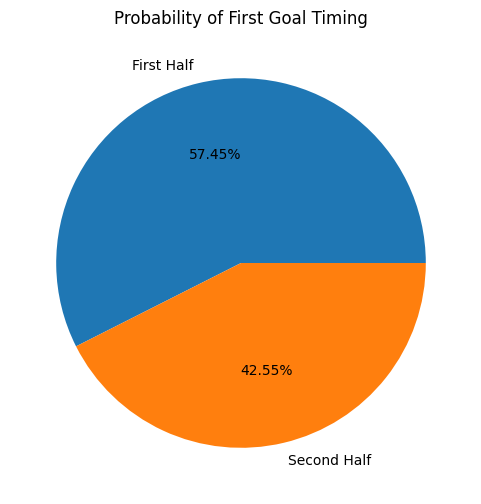

In [6]:
labels = ['First Half', 'Second Half']
sizes = [prob_first_half, prob_second_half]
plt.figure(figsize=(6,6))
plt.pie(sizes,labels=labels,autopct='%1.2f%%')
plt.title("Probability of First Goal Timing")
plt.show()

Probability of 1st goal in First Half: 0.57
Probability of 1st goal in Second Half: 0.43


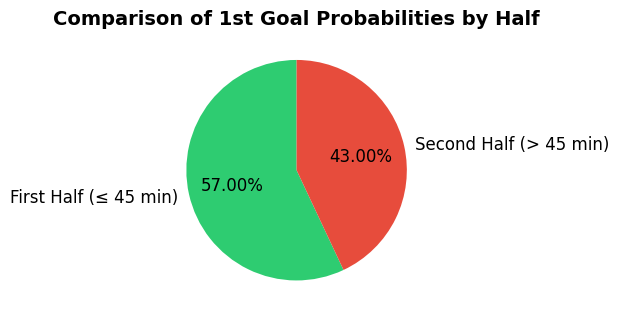

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter out matches that ended in a 0-0 draw (where 1st Goal is missing)
# This gives us only the matches where a first goal actually exists.
valid_goals = results[results['1st Goal'].notna()]

# 2. Count how many matches had their first goal in each half
# (Using the standard 45-minute mark boundary)
first_half_count = len(valid_goals[valid_goals['1st Goal'] <= 45])
second_half_count = len(valid_goals[valid_goals['1st Goal'] > 45])
total_goals_count = len(valid_goals)

# 3. Calculate the probabilities
prob_first_half = first_half_count / total_goals_count
prob_second_half = second_half_count / total_goals_count

# 4. Round the probabilities to two decimals as requested by the exam sheet
prob_first_half_round = round(prob_first_half, 2)
prob_second_half_round = round(prob_second_half, 2)

# Display the required calculated probabilities
print(f"Probability of 1st goal in First Half: {prob_first_half_round}")
print(f"Probability of 1st goal in Second Half: {prob_second_half_round}")

# 5. Compare the probabilities by means of a pie chart
labels = ['First Half (≤ 45 min)', 'Second Half (> 45 min)']
probabilities = [prob_first_half_round, prob_second_half_round]
colors = ['#2ecc71', '#e74c3c'] # Clean green and red layout colors

plt.figure(figsize=(6, 6))
plt.pie(
    probabilities, 
    labels=labels, 
    colors=colors, 
    autopct='%1.2f%%', # Formats values nicely as percentages inside slices
    startangle=90,     # Rotates chart cleanly
    textprops={'fontsize': 12}
)

plt.title("Comparison of 1st Goal Probabilities by Half", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
results.isnull().sum()

Date                        0
Team                        0
Opponent                    0
Goal Scored                 0
Ball Possession %           0
Attempts                    0
On-Target                   0
Off-Target                  0
Blocked                     0
Corners                     0
Offsides                    0
Free Kicks                  0
Saves                       0
Pass Accuracy %             0
Passes                      0
Distance Covered (Kms)      0
Fouls Committed             0
Yellow Card                 0
Yellow & Red                0
Red                         0
Man of the Match            0
1st Goal                   34
Round                       0
PSO                         0
Goals in PSO                0
Own goals                 116
Own goal Time             116
dtype: int64

In [9]:
missing_values= results.isnull().sum().sort_values(ascending = False)
percentage_missing_values = (missing_values/len(results))*100
pd.concat([missing_values, percentage_missing_values], axis = 1, keys= ['Missing values', '% Missing'])

,Missing values,% Missing
Own goal Time,116,90.6250
Own goals,116,90.6250
1st Goal,34,26.5625
Goal Scored,0,0.0000
Ball Possession %,0,0.0000
Attempts,0,0.0000
On-Target,0,0.0000
Off-Target,0,0.0000
Date,0,0.0000
Team,0,0.0000


In [10]:
## Too many missing values for Own Goal and Own goal time
## Best to replace the first goal with an average since its a float value
results.drop(['Own goals', 'Own goal Time'], axis=1, inplace=True)
results['1st Goal'] = results['1st Goal'].fillna(results['1st Goal'].mean())

In [11]:
results.isnull().sum()

Date                      0
Team                      0
Opponent                  0
Goal Scored               0
Ball Possession %         0
Attempts                  0
On-Target                 0
Off-Target                0
Blocked                   0
Corners                   0
Offsides                  0
Free Kicks                0
Saves                     0
Pass Accuracy %           0
Passes                    0
Distance Covered (Kms)    0
Fouls Committed           0
Yellow Card               0
Yellow & Red              0
Red                       0
Man of the Match          0
1st Goal                  0
Round                     0
PSO                       0
Goals in PSO              0
dtype: int64

In [12]:
results.drop(['Date'], axis=1, inplace=True)
results.head()

,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,Offsides,...,Distance Covered (Kms),Fouls Committed,Yellow Card,Yellow & Red,Red,Man of the Match,1st Goal,Round,PSO,Goals in PSO
0,Russia,Saudi Arabia,5,40,13,7,3,3,6,3,...,118,22,0,0,0,Yes,12.000000,Group Stage,No,0
1,Saudi Arabia,Russia,0,60,6,0,3,3,2,1,...,105,10,0,0,0,No,39.457447,Group Stage,No,0
2,Egypt,Uruguay,0,43,8,3,3,2,0,1,...,112,12,2,0,0,No,39.457447,Group Stage,No,0
3,Uruguay,Egypt,1,57,14,4,6,4,5,1,...,111,6,0,0,0,Yes,89.000000,Group Stage,No,0
4,Morocco,Iran,0,64,13,3,6,4,5,0,...,101,22,1,0,0,No,39.457447,Group Stage,No,0


In [13]:
print(f"Team: {results['Team'].unique()}\n")
print(f"Opponent: {results['Opponent'].unique()}\n")
print(f"Man of the Match: {results['Man of the Match'].unique()}\n")
print(f"Round: {results['Round'].unique()}\n")
print(f"PSO: {results['PSO'].unique()}\n")

Team: <StringArray>
[        'Russia',   'Saudi Arabia',          'Egypt',        'Uruguay',
        'Morocco',           'Iran',       'Portugal',          'Spain',
         'France',      'Australia',      'Argentina',        'Iceland',
           'Peru',        'Denmark',        'Croatia',        'Nigeria',
     'Costa Rica',         'Serbia',        'Germany',         'Mexico',
         'Brazil',    'Switzerland',         'Sweden', 'Korea Republic',
        'Belgium',         'Panama',        'Tunisia',        'England',
       'Colombia',          'Japan',         'Poland',        'Senegal']
Length: 32, dtype: str

Opponent: <StringArray>
[  'Saudi Arabia',         'Russia',        'Uruguay',          'Egypt',
           'Iran',        'Morocco',          'Spain',       'Portugal',
      'Australia',         'France',        'Iceland',      'Argentina',
        'Denmark',           'Peru',        'Nigeria',        'Croatia',
         'Serbia',     'Costa Rica',         'Mexico',  

In [14]:
label_encoder = LabelEncoder()

results['Man of the Match'] = label_encoder.fit_transform(results['Man of the Match'])
results['PSO'] = label_encoder.fit_transform(results['PSO'])

results.head(10)

,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,Offsides,...,Distance Covered (Kms),Fouls Committed,Yellow Card,Yellow & Red,Red,Man of the Match,1st Goal,Round,PSO,Goals in PSO
0,Russia,Saudi Arabia,5,40,13,7,3,3,6,3,...,118,22,0,0,0,1,12.000000,Group Stage,0,0
1,Saudi Arabia,Russia,0,60,6,0,3,3,2,1,...,105,10,0,0,0,0,39.457447,Group Stage,0,0
2,Egypt,Uruguay,0,43,8,3,3,2,0,1,...,112,12,2,0,0,0,39.457447,Group Stage,0,0
3,Uruguay,Egypt,1,57,14,4,6,4,5,1,...,111,6,0,0,0,1,89.000000,Group Stage,0,0
4,Morocco,Iran,0,64,13,3,6,4,5,0,...,101,22,1,0,0,0,39.457447,Group Stage,0,0
5,Iran,Morocco,1,36,8,2,5,1,2,0,...,100,14,3,0,0,1,90.000000,Group Stage,0,0
6,Portugal,Spain,3,39,8,3,2,3,4,1,...,102,12,1,0,0,0,4.000000,Group Stage,0,0
7,Spain,Portugal,3,61,12,5,5,2,5,3,...,103,10,1,0,0,1,24.000000,Group Stage,0,0
8,France,Australia,2,51,12,5,4,3,5,0,...,103,16,1,0,0,1,58.000000,Group Stage,0,0
9,Australia,France,1,49,4,1,2,1,1,0,...,111,19,3,0,0,0,62.000000,Group Stage,0,0


In [15]:
round_values = list(results['Round'].unique())
round_mappings = {label: index for index, label in enumerate(round_values)}
round_mappings

{'Group Stage': 0,
 'Round of 16': 1,
 'Quarter Finals': 2,
 'Semi- Finals': 3,
 '3rd Place': 4,
 'Final': 5}

In [16]:
results['Round'] = results['Round'].apply(lambda x: round_mappings[x])
results.head(10)

,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,Offsides,...,Distance Covered (Kms),Fouls Committed,Yellow Card,Yellow & Red,Red,Man of the Match,1st Goal,Round,PSO,Goals in PSO
0,Russia,Saudi Arabia,5,40,13,7,3,3,6,3,...,118,22,0,0,0,1,12.000000,0,0,0
1,Saudi Arabia,Russia,0,60,6,0,3,3,2,1,...,105,10,0,0,0,0,39.457447,0,0,0
2,Egypt,Uruguay,0,43,8,3,3,2,0,1,...,112,12,2,0,0,0,39.457447,0,0,0
3,Uruguay,Egypt,1,57,14,4,6,4,5,1,...,111,6,0,0,0,1,89.000000,0,0,0
4,Morocco,Iran,0,64,13,3,6,4,5,0,...,101,22,1,0,0,0,39.457447,0,0,0
5,Iran,Morocco,1,36,8,2,5,1,2,0,...,100,14,3,0,0,1,90.000000,0,0,0
6,Portugal,Spain,3,39,8,3,2,3,4,1,...,102,12,1,0,0,0,4.000000,0,0,0
7,Spain,Portugal,3,61,12,5,5,2,5,3,...,103,10,1,0,0,1,24.000000,0,0,0
8,France,Australia,2,51,12,5,4,3,5,0,...,103,16,1,0,0,1,58.000000,0,0,0
9,Australia,France,1,49,4,1,2,1,1,0,...,111,19,3,0,0,0,62.000000,0,0,0


In [17]:
pd.get_dummies(results['Team'],dtype=int)
pd.get_dummies(results['Opponent'].apply(lambda x: "opp_" + x),dtype=int)
results['Opponent'] = results['Opponent'].apply(lambda x: "opp_" + x)
results.head(10)

,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,Offsides,...,Distance Covered (Kms),Fouls Committed,Yellow Card,Yellow & Red,Red,Man of the Match,1st Goal,Round,PSO,Goals in PSO
0,Russia,opp_Saudi Arabia,5,40,13,7,3,3,6,3,...,118,22,0,0,0,1,12.000000,0,0,0
1,Saudi Arabia,opp_Russia,0,60,6,0,3,3,2,1,...,105,10,0,0,0,0,39.457447,0,0,0
2,Egypt,opp_Uruguay,0,43,8,3,3,2,0,1,...,112,12,2,0,0,0,39.457447,0,0,0
3,Uruguay,opp_Egypt,1,57,14,4,6,4,5,1,...,111,6,0,0,0,1,89.000000,0,0,0
4,Morocco,opp_Iran,0,64,13,3,6,4,5,0,...,101,22,1,0,0,0,39.457447,0,0,0
5,Iran,opp_Morocco,1,36,8,2,5,1,2,0,...,100,14,3,0,0,1,90.000000,0,0,0
6,Portugal,opp_Spain,3,39,8,3,2,3,4,1,...,102,12,1,0,0,0,4.000000,0,0,0
7,Spain,opp_Portugal,3,61,12,5,5,2,5,3,...,103,10,1,0,0,1,24.000000,0,0,0
8,France,opp_Australia,2,51,12,5,4,3,5,0,...,103,16,1,0,0,1,58.000000,0,0,0
9,Australia,opp_France,1,49,4,1,2,1,1,0,...,111,19,3,0,0,0,62.000000,0,0,0


In [18]:
results_clean = pd.concat([results, pd.get_dummies(results['Team'],dtype=int), pd.get_dummies(results['Opponent'],dtype=int)], axis=1)
results_clean.head(10)

,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,Offsides,...,opp_Portugal,opp_Russia,opp_Saudi Arabia,opp_Senegal,opp_Serbia,opp_Spain,opp_Sweden,opp_Switzerland,opp_Tunisia,opp_Uruguay
0,Russia,opp_Saudi Arabia,5,40,13,7,3,3,6,3,...,0,0,1,0,0,0,0,0,0,0
1,Saudi Arabia,opp_Russia,0,60,6,0,3,3,2,1,...,0,1,0,0,0,0,0,0,0,0
2,Egypt,opp_Uruguay,0,43,8,3,3,2,0,1,...,0,0,0,0,0,0,0,0,0,1
3,Uruguay,opp_Egypt,1,57,14,4,6,4,5,1,...,0,0,0,0,0,0,0,0,0,0
4,Morocco,opp_Iran,0,64,13,3,6,4,5,0,...,0,0,0,0,0,0,0,0,0,0
5,Iran,opp_Morocco,1,36,8,2,5,1,2,0,...,0,0,0,0,0,0,0,0,0,0
6,Portugal,opp_Spain,3,39,8,3,2,3,4,1,...,0,0,0,0,0,1,0,0,0,0
7,Spain,opp_Portugal,3,61,12,5,5,2,5,3,...,1,0,0,0,0,0,0,0,0,0
8,France,opp_Australia,2,51,12,5,4,3,5,0,...,0,0,0,0,0,0,0,0,0,0
9,Australia,opp_France,1,49,4,1,2,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
results_clean.drop(['Team', 'Opponent'], axis=1, inplace=True)
results_clean.head(10)

,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,Offsides,Free Kicks,Saves,...,opp_Portugal,opp_Russia,opp_Saudi Arabia,opp_Senegal,opp_Serbia,opp_Spain,opp_Sweden,opp_Switzerland,opp_Tunisia,opp_Uruguay
0,5,40,13,7,3,3,6,3,11,0,...,0,0,1,0,0,0,0,0,0,0
1,0,60,6,0,3,3,2,1,25,2,...,0,1,0,0,0,0,0,0,0,0
2,0,43,8,3,3,2,0,1,7,3,...,0,0,0,0,0,0,0,0,0,1
3,1,57,14,4,6,4,5,1,13,3,...,0,0,0,0,0,0,0,0,0,0
4,0,64,13,3,6,4,5,0,14,2,...,0,0,0,0,0,0,0,0,0,0
5,1,36,8,2,5,1,2,0,22,2,...,0,0,0,0,0,0,0,0,0,0
6,3,39,8,3,2,3,4,1,13,2,...,0,0,0,0,0,1,0,0,0,0
7,3,61,12,5,5,2,5,3,13,0,...,1,0,0,0,0,0,0,0,0,0
8,2,51,12,5,4,3,5,0,19,1,...,0,0,0,0,0,0,0,0,0,0
9,1,49,4,1,2,1,1,0,16,4,...,0,0,0,0,0,0,0,0,0,0


In [20]:
results_clean.dtypes

Goal Scored          int64
Ball Possession %    int64
Attempts             int64
On-Target            int64
Off-Target           int64
                     ...  
opp_Spain            int64
opp_Sweden           int64
opp_Switzerland      int64
opp_Tunisia          int64
opp_Uruguay          int64
Length: 86, dtype: object

In [29]:
corr = results_clean.iloc[:,0:22].corr()
corr = corr[['Man of the Match']]
corr

,Man of the Match
Goal Scored,5.221929e-01
Ball Possession %,1.103928e-01
Attempts,1.764254e-01
On-Target,2.913465e-01
Off-Target,1.529793e-01
Blocked,-1.958193e-02
Corners,1.731481e-01
Offsides,2.628850e-02
Free Kicks,1.195341e-01
Saves,-3.444284e-02


Text(0.5, 1.0, 'Heatmap of Correlation')

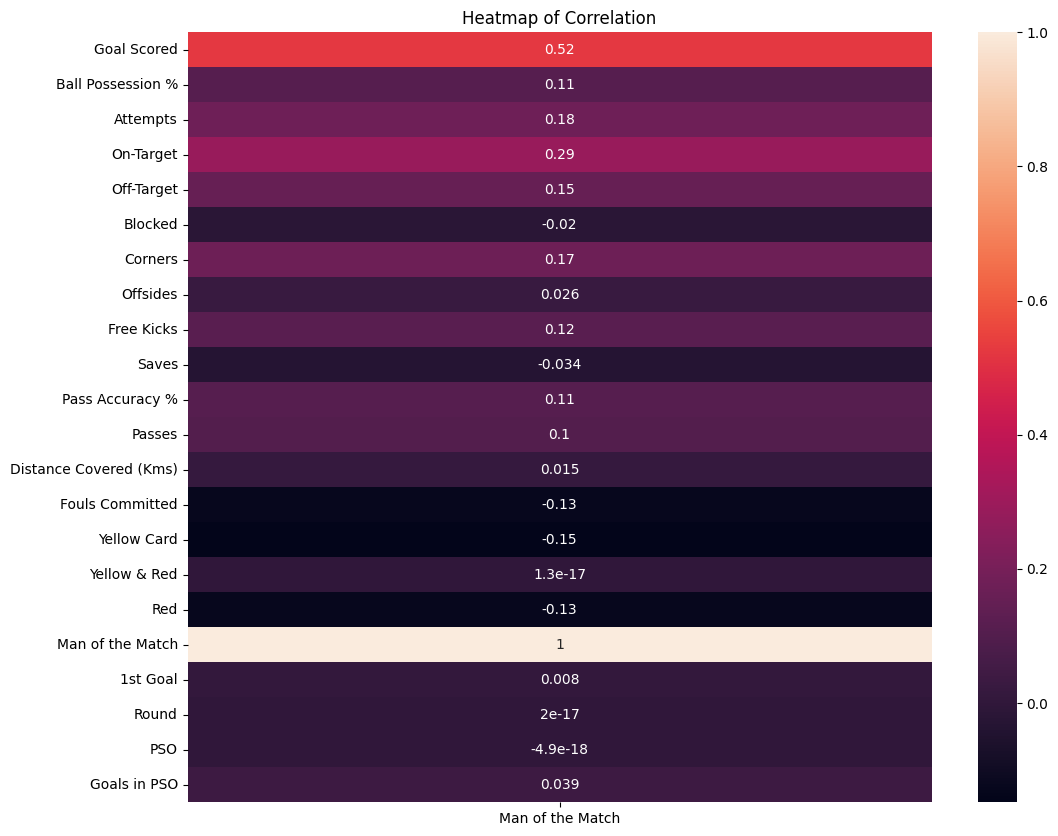

In [30]:
plt.figure(figsize = (12,10))
heat = sns.heatmap(data = corr, annot = True)
plt.title('Heatmap of Correlation')

Question 2.7.1 Answer Draft
1. Examination of the Correlation Vector
Looking closely at the Man of the Match column row in the generated heatmap:

Goal Scored shows the strongest positive linear correlation with a value of 0.52.

On-Target attempts follow next with a positive correlation value of 0.29.

Attempts overall also show a mild positive correlation of 0.18.

Most defensive or structural features like Blocked (-0.02), Saves (-0.034), and Fouls Committed (-0.13) exhibit near-zero or mildly negative correlations.

2. Statistical Inferences
From these values, we can draw the following conclusions about what influences a player winning the Man of the Match award in this dataset:

Attacking Impact is King: The high correlation of 0.52 indicates that scoring goals is the single most influential factor in determining the award winner. A player or team that finds the back of the net frequently dramatically raises their statistical likelihood of securing the accolade.

Efficiency Matters More Than Volume: The correlation for shots hitting the target (On-Target: 0.29) is noticeably higher than total shots taken (Attempts: 0.18). This tells us that offensive efficiency and testing the goalkeeper carry more weight in predictive outcomes than simply shooting wildly or frequently.

Defensive Metrics have Little Predictive Power: The negligible and slightly negative correlations among defensive parameters imply that clean sheets, tackles, saves, or fouls do not heavily factor into who gets chosen for the award relative to attacking metrics in this specific data sample. The model will likely rely heavily on offensive metrics to make high-accuracy predictions.

In [31]:
from sklearn.model_selection import train_test_split

X = results_clean.drop(['Man of the Match'],axis = 1)
y= results_clean['Man of the Match'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 13)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)
scaler.fit(X_test)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(102, 85)
(102,)
(26, 85)
(26,)


NB(acc): 0.536364 (0.158140)
NB(f1): 0.532214 (0.163445)


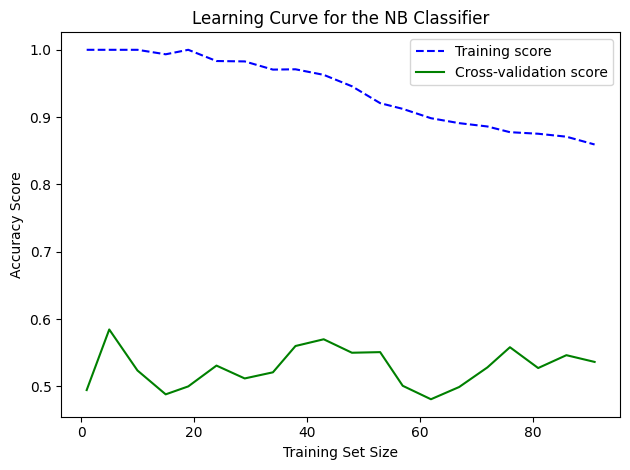

LR(acc): 0.634545 (0.170841)
LR(f1): 0.634626 (0.178392)


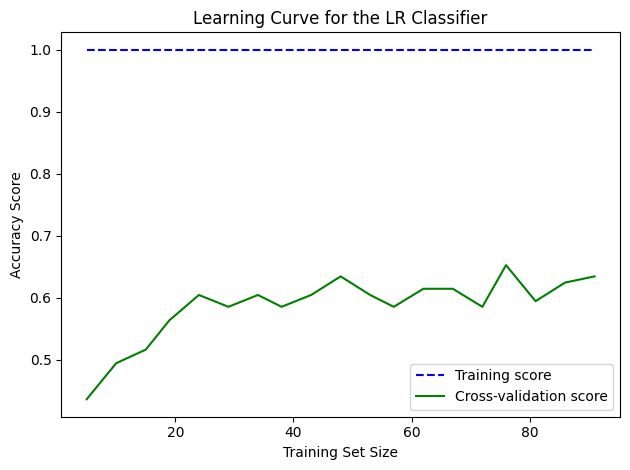

CART(acc): 0.608182 (0.139150)
CART(f1): 0.640133 (0.125440)


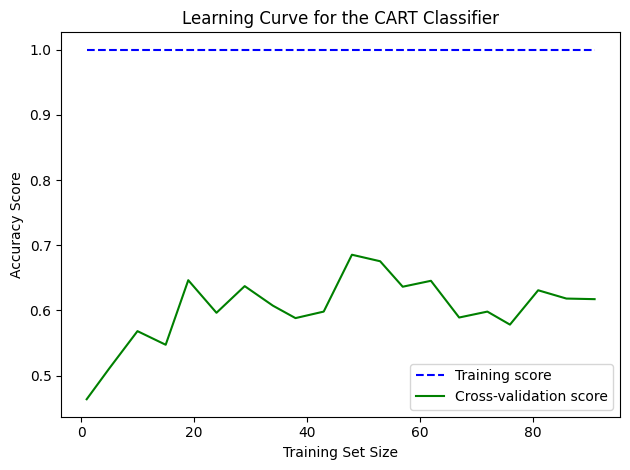

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve

from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer

models = []

models.append(('NB', GaussianNB()))
models.append(('LR',LogisticRegression(max_iter=1000)))
models.append(('CART', DecisionTreeClassifier()))


results = []
names =[]

f1 = make_scorer(f1_score,average = 'weighted')

for name,model in models:
    kfold =KFold(n_splits = 10,random_state=13,shuffle= True)
    cv_results = cross_val_score(model,X_train,y_train,cv=kfold,scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    msg='%s(acc): %f (%f)' % (name,cv_results.mean(),cv_results.std())
    print(msg)
    cv_results = cross_val_score(model, X_train, y_train, cv = kfold, scoring = f1)
    results.append(cv_results)
    names.append(name)
    msg = '%s(f1): %f (%f)' % (name, cv_results.mean(), cv_results.std())
    print(msg)
    train_sizes, train_scores, validation_scores = learning_curve(estimator = model,
                                                              X = X_train,
                                                              y = y_train,
                                                              train_sizes = np.linspace(0.01, 1.0, 20),
                                                              cv = kfold,
                                                              scoring = 'accuracy', shuffle = True)
    mean_training = np.mean(train_scores, axis=1)
    mean_testing = np.mean(validation_scores, axis=1)


    
    plt.plot(train_sizes, mean_training, '--', color = "b",  label = "Training score")
    plt.plot(train_sizes, mean_testing, color = "g", label = "Cross-validation score")
    plt.title(f"Learning Curve for the " + name + " Classifier")
    plt.xlabel("Training Set Size"), plt.ylabel("Accuracy Score"), plt.legend(loc = "best")
    plt.tight_layout()
    plt.show()

In [38]:
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(metrics.accuracy_score(predictions, y_test))
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

0.7692307692307693
[[11  4]
 [ 2  9]]
              precision    recall  f1-score   support

           0       0.85      0.73      0.79        15
           1       0.69      0.82      0.75        11

    accuracy                           0.77        26
   macro avg       0.77      0.78      0.77        26
weighted avg       0.78      0.77      0.77        26



In [39]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=13)
dummy_clf.fit(X_train, y_train)
dummy_predictions = dummy_clf.predict(X_test)

dummy_acc = metrics.accuracy_score(dummy_predictions, y_test)
dummy_f1  = f1_score(y_test, dummy_predictions, average='weighted', zero_division=0)
model_acc = metrics.accuracy_score(predictions, y_test)
model_f1  = f1_score(y_test, predictions, average='weighted', zero_division=0)

comparison = pd.DataFrame({
    'Accuracy': [model_acc, dummy_acc],
    'F1 Score': [model_f1,  dummy_f1]
}, index=['Decision Tree', 'Dummy Classifier']).round(4)

print('Model vs Dummy Classifier Comparison:')
print(comparison)

Model vs Dummy Classifier Comparison:
                  Accuracy  F1 Score
Decision Tree       0.7692    0.7706
Dummy Classifier    0.4231    0.2516
